At this step we download the MNIST dataset by using the keras library

In [10]:
#Import all necessary libraries

from tensorflow.keras.datasets import mnist
import numpy as np
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, make_scorer
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, cross_validate, StratifiedKFold
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import roc_curve, roc_auc_score, RocCurveDisplay
import matplotlib.pyplot as plt

# Force the framework will automatically run on CPU to avoid display warnings
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

# Download and load MNIST dataset
(X_train_all, y_train_all), (X_test, y_test) = mnist.load_data()

print("======================================================================")
# MNIST dataset is by default devided in 60000/10000 parts for training and testing
# This info is displayed as follows
# Check dataset sizes
print("Training data shape:", X_train_all.shape)
print("Training labels shape:", y_train_all.shape)
print("Test data shape:", X_test.shape)
print("Test labels shape:", y_test.shape)

# Combine into a single dataset to ensure exact splits
X = np.concatenate((X_train_all, X_test), axis=0)
y = np.concatenate((y_train_all, y_test), axis=0)

# Normalize pixel values between 0 and 1
X = X.astype('float32') / 255.0

# Flatten images for KNN because it expects 2D input
X = X.reshape((X.shape[0], -1))  # shape = (70000, 784)

Training data shape: (60000, 28, 28)
Training labels shape: (60000,)
Test data shape: (10000, 28, 28)
Test labels shape: (10000,)


Creation of binary classification (1 for odd - 0 for even) by dividing with the appropriate number

In [11]:
# Convert to binary labels: 0 = even, 1 = odd
y_binary = np.where(y % 2 == 0, 0, 1)

# Evaluation of process by displaying the first 10 digits of the converted data against the original
print("Example labels before:", y[:10])
print("Example binary labels after:", y_binary[:10])

Example labels before: [5 0 4 1 9 2 1 3 1 4]
Example binary labels after: [1 0 0 1 1 0 1 1 1 0]


In [12]:
# Utilization of KNeighborsClassifier.
# Data has already been normalized in the previous step

# Split data into training (60,000) and test (10,000)
X_train, X_test, y_train, y_test = train_test_split(
    X, y_binary, train_size=60000, test_size=10000, random_state=42, stratify=y_binary
)

print(f"Train set: {X_train.shape}, Test set: {X_test.shape}")

# Define specific k values (3,5 and 7)
n_values = {'n_neighbors': [3, 5, 7]}

# Define the model
knn = KNeighborsClassifier()

# Prepare parameters for grid search with 3-fold cross-validation
grid_search = GridSearchCV(
    knn,
    n_values,
    cv=3,
    scoring='accuracy',
    n_jobs=-1,
    verbose=2
)

# Perform grid search with 3-fold cross-validation
grid_search.fit(X_train, y_train)

# Display the best parameters and accuracy
print("Best Parameters:", grid_search.best_params_)
print("Best Cross-Validation Accuracy:", grid_search.best_score_)

# Evaluate on test set using best model
best_knn_model = grid_search.best_estimator_

# Predictions on test data
y_pred = best_knn_model.predict(X_test)

Train set: (60000, 784), Test set: (10000, 784)
Fitting 3 folds for each of 3 candidates, totalling 9 fits
Best Parameters: {'n_neighbors': 3}
Best Cross-Validation Accuracy: 0.9828


Evaluation of model's performance

In [13]:
# Information Message
print("Be patient. It will take some time...")

# Calculate evaluation metrics
test_accuracy = accuracy_score(y_test, y_pred)
test_precision = precision_score(y_test, y_pred)
test_recall = recall_score(y_test, y_pred)

print("\n📊 Final Test Set Evaluation:")
print(f"Accuracy : {test_accuracy:.4f}")
print(f"Precision: {test_precision:.4f}")
print(f"Recall   : {test_recall:.4f}")

# Cross-validate metrics (3-fold CV)
scoring = {
    'accuracy': make_scorer(accuracy_score),
    'precision': make_scorer(precision_score),
    'recall': make_scorer(recall_score)
}

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
cv_results = cross_validate(best_knn_model, X_train, y_train, cv=cv, scoring=scoring)

print("3-Fold Cross-Validation Results (Training set):")
print(f"Mean Accuracy : {cv_results['test_accuracy'].mean():.4f}")
print(f"Mean Precision: {cv_results['test_precision'].mean():.4f}")
print(f"Mean Recall   : {cv_results['test_recall'].mean():.4f}")

Be patient. It will take some time...

📊 Final Test Set Evaluation:
Accuracy : 0.9859
Precision: 0.9813
Recall   : 0.9911
3-Fold Cross-Validation Results (Training set):
Mean Accuracy : 0.9829
Mean Precision: 0.9767
Mean Recall   : 0.9898


Creation of Confusion matrix

Confusion Matrix:
[[4821   96]
 [  45 5038]]


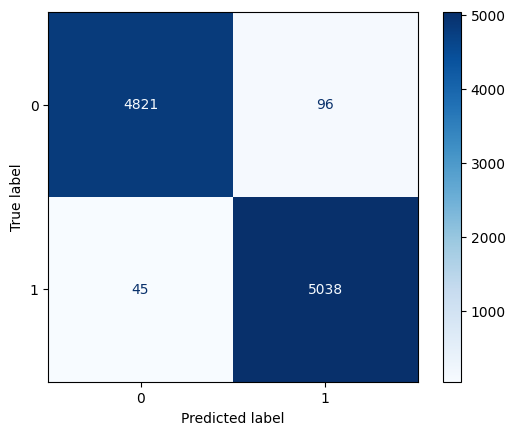

In [14]:
# Compute the confusion matrix based on model's predictions
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

# Display confusion matrix as plot
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')

Calculation and display ROC curve and AUC


 ROC AUC: 0.9946


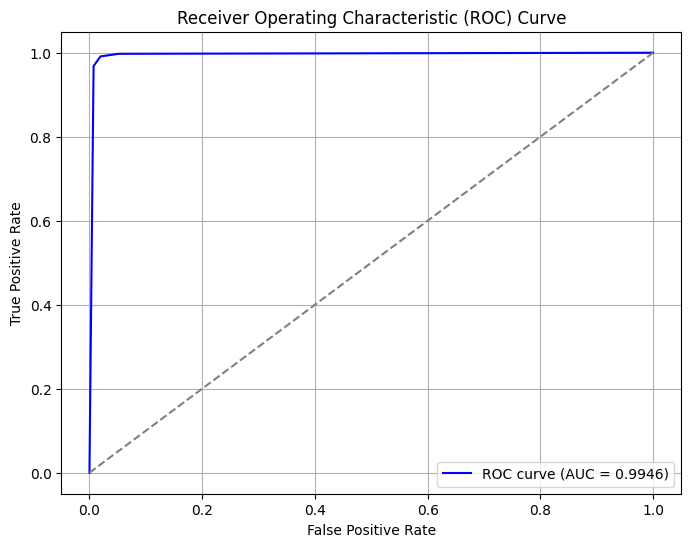

[CV] END ......................................n_neighbors=3; total time=  52.3s
[CV] END ......................................n_neighbors=5; total time=  52.1s
[CV] END ......................................n_neighbors=5; total time=  52.5s
[CV] END ......................................n_neighbors=7; total time=  51.8s
[CV] END ......................................n_neighbors=3; total time=  53.0s
[CV] END ......................................n_neighbors=7; total time=  52.4s
[CV] END ......................................n_neighbors=3; total time=  51.6s
[CV] END ......................................n_neighbors=5; total time=  49.5s
[CV] END ......................................n_neighbors=7; total time=  35.9s


In [15]:
# Get predicted probabilities for the positive class (usually class 1)
y_proba = best_knn_model.predict_proba(X_test)[:, 1]

# Compute ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
roc_auc = roc_auc_score(y_test, y_proba)

print(f"\n ROC AUC: {roc_auc:.4f}")

# Plot the ROC Curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')  # random classifier line
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()